In [ ]:
# Nigeria LPG Facility Probability Model & Allocation Parameters

# This script:
# 1. Aligns population, urban, income, and friction rasters.
# 2. Computes urban/rural facility counts and LPG user estimates.
# 3. Builds a cell‑level dataset (presence/absence + predictors).
# 4. Fits logistic regression models for resellers and filling stations.
# 5. Calculates median nearest‑neighbour distances (for anti‑clustering).
# 6. Exports the models and parameters for use in other countries.

import os
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.transform import rowcol
from rasterio.warp import reproject, Resampling
from scipy.stats import pearsonr
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import pickle
import random
from scipy.spatial import cKDTree
from scipy.ndimage import convolve

# ============================
# PARAMETERS
# ============================
DATA_DIR = "SSA/nige_dataset"
GPKG_NAME = "full_lpg_chain_nig_3857.gpkg"
POP_TIF   = "population.tif"
URBAN_TIF = "urban.tif"
INCOME_TIF = "income_nigeria.tif"
FRICTION_TIF = "friction_moto.tif"          # minutes per meter (motorized)

URBAN_SHARE = 0.25468      # ONSTOVE urban LPG adoption share
RURAL_SHARE = 0.027905     # ONSTOVE rural LPG adoption share
URBAN_THRESHOLD = 20       # value in urban.tif above which a cell is "urban"
TARGET_CRS = "EPSG:3857"
CATCHMENT_RADIUS_KM = 5.0  # as litterature suggests, reasonable catchment radius.

# -----------------------------------------------------------------
# 1. LOAD VECTOR DATA
# -----------------------------------------------------------------
gpkg_path = os.path.join(DATA_DIR, GPKG_NAME)
resell = gpd.read_file(gpkg_path, layer='resell')
filling = gpd.read_file(gpkg_path, layer='filling')

if resell.crs != TARGET_CRS:
    resell = resell.to_crs(TARGET_CRS)
if filling.crs != TARGET_CRS:
    filling = filling.to_crs(TARGET_CRS)

print(f"Resellers: {len(resell)}  Filling: {len(filling)}")

# -----------------------------------------------------------------
# 2. LOAD & ALIGN RASTERS
# -----------------------------------------------------------------
pop_path   = os.path.join(DATA_DIR, POP_TIF)
urb_path   = os.path.join(DATA_DIR, URBAN_TIF)
inc_path   = os.path.join(DATA_DIR, INCOME_TIF)
fric_path  = os.path.join(DATA_DIR, FRICTION_TIF)

# Reference raster (population)
with rasterio.open(pop_path) as ref:
    ref_shape = ref.shape
    ref_transform = ref.transform
    ref_crs = ref.crs
    ref_nodata = ref.nodata
    pop_data = ref.read(1).astype(float)
    if ref_nodata is not None:
        pop_data[pop_data == ref_nodata] = np.nan

def align_raster(src_path, ref_shape, ref_transform, ref_crs):
    """Resample a raster to the reference grid; return array with nodata->NaN."""
    with rasterio.open(src_path) as src:
        resampled = np.empty(ref_shape, dtype=np.float32)
        reproject(
            source=rasterio.band(src, 1),
            destination=resampled,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=ref_transform,
            dst_crs=ref_crs,
            resampling=Resampling.bilinear
        )
        src_nodata = src.nodata
        if src_nodata is not None:
            resampled[resampled == src_nodata] = np.nan
        return resampled

def compute_neighborhood_sum(raster_array, radius_km, pixel_size_m):
    """Calculates the total sum of a variable within a circular radius (e.g., total population around a cell)."""
    radius_pixels = int(round((radius_km * 1000) / pixel_size_m))
    y, x = np.ogrid[-radius_pixels:radius_pixels+1, -radius_pixels:radius_pixels+1]
    kernel = (x**2 + y**2 <= radius_pixels**2).astype(float)
    
    # Temporarily replace NaNs with 0 to prevent NaN propagation during convolution
    mask_nan = np.isnan(raster_array)
    clean_array = np.where(mask_nan, 0.0, raster_array)
    
    smoothed = convolve(clean_array, kernel, mode='constant', cval=0.0)
    smoothed[mask_nan] = np.nan
    return smoothed

def compute_neighborhood_mean(raster_array, radius_km, pixel_size_m):
    """Calculates the true average of a variable within a circular radius, ignoring NaNs."""
    radius_pixels = int(round((radius_km * 1000) / pixel_size_m))
    y, x = np.ogrid[-radius_pixels:radius_pixels+1, -radius_pixels:radius_pixels+1]
    kernel = (x**2 + y**2 <= radius_pixels**2).astype(float)
    
    mask_valid = (~np.isnan(raster_array)).astype(float)
    clean_array = np.where(np.isnan(raster_array), 0.0, raster_array)
    
    # Calculate the sum of values and count of valid pixels within the window
    sum_spatial = convolve(clean_array, kernel, mode='constant', cval=0.0)
    count_spatial = convolve(mask_valid, kernel, mode='constant', cval=0.0)
    
    # Avoid zero division
    with np.errstate(divide='ignore', invalid='ignore'):
        mean_spatial = np.where(count_spatial > 0, sum_spatial / count_spatial, np.nan)
    
    mean_spatial[np.isnan(raster_array)] = np.nan
    return mean_spatial

urban_data = align_raster(urb_path, ref_shape, ref_transform, ref_crs)
income_data = align_raster(inc_path, ref_shape, ref_transform, ref_crs)
friction_data = align_raster(fric_path, ref_shape, ref_transform, ref_crs)

# Urban / rural mask
urban_mask = (urban_data >= URBAN_THRESHOLD) & (~np.isnan(urban_data))
rural_mask = (urban_data < URBAN_THRESHOLD) & (~np.isnan(urban_data))
print(f"All rasters aligned to shape {ref_shape}")

# Extract pixel dimension (in meters) from your CRS transform
pixel_size_m = abs(ref_transform[0]) 

# Define the market catchment radius (5 km is standard for urban/semi-urban retail logic)
print(f"Engineering spatial catchment features using a {CATCHMENT_RADIUS_KM}km moving window...")

# 1. Total population available to a facility placed in this cell
pop_neighborhood = compute_neighborhood_sum(pop_data, CATCHMENT_RADIUS_KM, pixel_size_m)

# 2. Average wealth index surrounding this cell
income_neighborhood = compute_neighborhood_mean(income_data, CATCHMENT_RADIUS_KM, pixel_size_m)

# 3. Average logistics friction surrounding this cell
friction_neighborhood = compute_neighborhood_mean(friction_data, CATCHMENT_RADIUS_KM, pixel_size_m)



# -----------------------------------------------------------------
# 3. BASIC COUNTS & LPG USER ESTIMATES
# -----------------------------------------------------------------
def point_in_mask(gdf, mask, transform):
    coords = [(p.x, p.y) for p in gdf.geometry]
    rows, cols = zip(*[rowcol(transform, x, y) for x, y in coords])
    rows, cols = np.array(rows), np.array(cols)
    valid = (rows >= 0) & (rows < mask.shape[0]) & (cols >= 0) & (cols < mask.shape[1])
    in_mask = np.zeros(len(gdf), dtype=bool)
    if np.any(valid):
        in_mask[valid] = mask[rows[valid], cols[valid]]
    return in_mask

res_urban = point_in_mask(resell, urban_mask, ref_transform)
res_rural = point_in_mask(resell, rural_mask, ref_transform)
fill_urban = point_in_mask(filling, urban_mask, ref_transform)
fill_rural = point_in_mask(filling, rural_mask, ref_transform)

n_res_urban = res_urban.sum()
n_res_rural = res_rural.sum()
n_fill_urban = fill_urban.sum()
n_fill_rural = fill_rural.sum()

urban_pop = np.nansum(pop_data[urban_mask])
rural_pop = np.nansum(pop_data[rural_mask])
urban_lpg = URBAN_SHARE * urban_pop
rural_lpg = RURAL_SHARE * rural_pop
total_lpg = urban_lpg + rural_lpg

res_per_1k_urban = n_res_urban / urban_lpg * 1000 if urban_lpg else np.nan
res_per_1k_rural = n_res_rural / rural_lpg * 1000 if rural_lpg else np.nan
fill_per_1k_urban = n_fill_urban / urban_lpg * 1000 if urban_lpg else np.nan
fill_per_1k_rural = n_fill_rural / rural_lpg * 1000 if rural_lpg else np.nan

print("\n--- Facility counts ---")
print(f"Resellers: urban {n_res_urban} ({100*n_res_urban/len(resell):.1f}%)  rural {n_res_rural} ({100*n_res_rural/len(resell):.1f}%)")
print(f"Filling:   urban {n_fill_urban} ({100*n_fill_urban/len(filling):.1f}%)  rural {n_fill_rural} ({100*n_fill_rural/len(filling):.1f}%)")
print("\n--- LPG users (millions) ---")
print(f"Urban: {urban_lpg/1e6:.2f}  Rural: {rural_lpg/1e6:.2f}  Total: {total_lpg/1e6:.2f}")
print("\n--- Facilities per 1000 LPG users ---")
print(f"Resellers: urban {res_per_1k_urban:.3f}  rural {res_per_1k_rural:.3f}")
print(f"Filling:   urban {fill_per_1k_urban:.3f}  rural {fill_per_1k_rural:.3f}")

# -----------------------------------------------------------------
# 4. BUILD CELL‑LEVEL TRAINING DATASET
# -----------------------------------------------------------------
# Create presence rasters (1 if at least one facility in cell)
def presence_raster(gdf, shape, transform):
    pres = np.zeros(shape, dtype=np.uint8)
    coords = [(p.x, p.y) for p in gdf.geometry]
    for x, y in coords:
        r, c = rowcol(transform, x, y)
        if 0 <= r < shape[0] and 0 <= c < shape[1]:
            pres[r, c] = 1
    return pres
valid_cells = (~np.isnan(pop_data)) & (~np.isnan(income_data)) & (~np.isnan(urban_data)) & (~np.isnan(friction_data))
res_pres = presence_raster(resell, ref_shape, ref_transform)
fill_pres = presence_raster(filling, ref_shape, ref_transform)

# Define a valid mask (all predictors non-NaN)
valid_cells = (~np.isnan(pop_data)) & (~np.isnan(income_data)) & (~np.isnan(urban_data)) & (~np.isnan(friction_data))
# Also exclude cells with zero population? (logistic can handle, but may add noise)
# Keep all valid cells

# Flatten
pop_flat = pop_neighborhood[valid_cells]
income_flat = income_neighborhood[valid_cells]
urban_flat = urban_mask[valid_cells].astype(np.uint8)   # Keep urban boundary as a strict 1 or 0 binary
friction_flat = friction_neighborhood[valid_cells]

res_flat = res_pres[valid_cells]
fill_flat = fill_pres[valid_cells]

# Prepare design matrix X
X = np.column_stack([income_flat, pop_flat, urban_flat, friction_flat])
y_res = res_flat
y_fill = fill_flat

# Normalize income and friction (optional, but useful for interpretation)
scaler_income = StandardScaler()
scaler_friction = StandardScaler()
scaler_pop = StandardScaler()

X_norm = X.copy()
X_norm[:,0] = scaler_income.fit_transform(income_flat.reshape(-1,1)).ravel()
X_norm[:,1] = scaler_pop.fit_transform(pop_flat.reshape(-1,1)).ravel()
X_norm[:,3] = scaler_friction.fit_transform(friction_flat.reshape(-1,1)).ravel()
# urban is already binary, no scaling needed

print(f"\nTraining cells: {X_norm.shape[0]}  (reseller presence: {y_res.sum()}, filling presence: {y_fill.sum()})")

# -----------------------------------------------------------------
# 5. FIT LOGISTIC REGRESSION MODELS
# -----------------------------------------------------------------
model_res = LogisticRegression(max_iter=1000, solver='lbfgs')
model_res.fit(X_norm, y_res)

model_fill = LogisticRegression(max_iter=1000, solver='lbfgs')
model_fill.fit(X_norm, y_fill)

# Coefficients
feature_names = ['income_norm', 'population_norm', 'is_urban', 'friction_norm']
coef_df = pd.DataFrame({
    'Reseller_coef': model_res.coef_[0],
    'Filling_coef': model_fill.coef_[0]
}, index=feature_names)
print("\nLogistic regression coefficients (normalized predictors):")
print(coef_df)

# Save models & scalers
os.makedirs('SSA/models', exist_ok=True)
with open('SSA/models/logres_reseller.pkl', 'wb') as f:
    pickle.dump(model_res, f)
with open('SSA/models/logres_filling.pkl', 'wb') as f:
    pickle.dump(model_fill, f)
with open('SSA/models/scaler_income.pkl', 'wb') as f:
    pickle.dump(scaler_income, f)
with open('SSA/models/scaler_population.pkl', 'wb') as f:
    pickle.dump(scaler_pop, f)
with open('SSA/models/scaler_friction.pkl', 'wb') as f:
    pickle.dump(scaler_friction, f)

# -----------------------------------------------------------------
# 6. NEAREST‑NEIGHBOUR STATISTICS
# -----------------------------------------------------------------
def median_nn_distance(gdf, transform, mask=None):
    """Median nearest-neighbour distance (in projected units, meters here) for points
    falling inside mask (if provided)."""
    if mask is not None:
        gdf_sub = gdf[point_in_mask(gdf, mask, transform)]
    else:
        gdf_sub = gdf
    if len(gdf_sub) <= 1:
        return np.nan
    coords = np.array([(p.x, p.y) for p in gdf_sub.geometry])
    tree = cKDTree(coords)
    distances, _ = tree.query(coords, k=2)   # closest is itself, second is nearest neighbour
    nn_dist = distances[:, 1]
    return np.median(nn_dist)

# All points
med_res = median_nn_distance(resell, ref_transform)
med_fill = median_nn_distance(filling, ref_transform)

# By urban/rural
med_res_urb = median_nn_distance(resell, ref_transform, urban_mask)
med_res_rur = median_nn_distance(resell, ref_transform, rural_mask)
med_fill_urb = median_nn_distance(filling, ref_transform, urban_mask)
med_fill_rur = median_nn_distance(filling, ref_transform, rural_mask)

print("\n--- Median nearest‑neighbour distances (meters) ---")
print(f"Resellers  : all {med_res:.0f}   urban {med_res_urb:.0f}   rural {med_res_rur:.0f}")
print(f"Filling    : all {med_fill:.0f}   urban {med_fill_urb:.0f}   rural {med_fill_rur:.0f}")

# Compute overall density for scaling
# Area per cell (assuming square cells in projected CRS, 3857)
dx = abs(ref_transform[0])   # pixel width in meters
area_cell_m2 = dx * dx       # assuming square pixels
area_km2 = (ref_shape[0] * ref_shape[1] * area_cell_m2) / 1e6
density_res = len(resell) / area_km2
density_fill = len(filling) / area_km2
print(f"\nFacility density (per km²): Resellers {density_res:.6f}  Filling {density_fill:.6f}")

# -----------------------------------------------------------------
# 7. SAVE SUMMARY PARAMETERS
# -----------------------------------------------------------------
params = {
    'facilities_per_1000_lpg_users': {
        'reseller_urban': res_per_1k_urban,
        'reseller_rural': res_per_1k_rural,
        'filling_urban': fill_per_1k_urban,
        'filling_rural': fill_per_1k_rural
    },
    'median_nn_distance_m': {
        'reseller_all': med_res, 'reseller_urban': med_res_urb, 'reseller_rural': med_res_rur,
        'filling_all': med_fill, 'filling_urban': med_fill_urb, 'filling_rural': med_fill_rur
    },
    'density_per_km2': {
        'reseller': density_res,
        'filling': density_fill
    },
    'urban_share': URBAN_SHARE,
    'rural_share': RURAL_SHARE,
    'urban_threshold': URBAN_THRESHOLD,
    'reference_crs': TARGET_CRS,
    'pixel_size_m': dx
}

with open('SSA/models/allocation_params.pkl', 'wb') as f:
    pickle.dump(params, f)

# Also export a readable CSV of coefficients
coef_df.to_csv('SSA/models/logistic_coefficients.csv')

print("\nAll models and parameters saved in ./models/")
print("Ready for allocation script.")

Resellers: 2413  Filling: 375
All rasters aligned to shape (1085, 1337)
Engineering spatial catchment features using a 5.0km moving window...

--- Facility counts ---
Resellers: urban 1959 (81.2%)  rural 454 (18.8%)
Filling:   urban 332 (88.5%)  rural 43 (11.5%)

--- LPG users (millions) ---
Urban: 21.06  Rural: 3.43  Total: 24.49

--- Facilities per 1000 LPG users ---
Resellers: urban 0.093  rural 0.133
Filling:   urban 0.016  rural 0.013

Training cells: 560042  (reseller presence: 1924, filling presence: 349)

Logistic regression coefficients (normalized predictors):
                 Reseller_coef  Filling_coef
income_norm           0.333090      0.574794
population_norm      -0.027617     -0.038339
is_urban              3.201267      1.810435
friction_norm        -0.373147     -1.089758

--- Median nearest‑neighbour distances (meters) ---
Resellers  : all 803   urban 694   rural 5276
Filling    : all 2109   urban 2084   rural 4469

Facility density (per km²): Resellers 0.001663  Fi


--- Starting Distance-Decay Neighborhood Analysis ---
Extracting cell spatial coordinates...
Building KD-Tree for proximity extraction...
Total cells processed within 100.0km radius: 549062
 -> Urban Catchment Cells: 18929
 -> Rural Catchment Cells: 530133


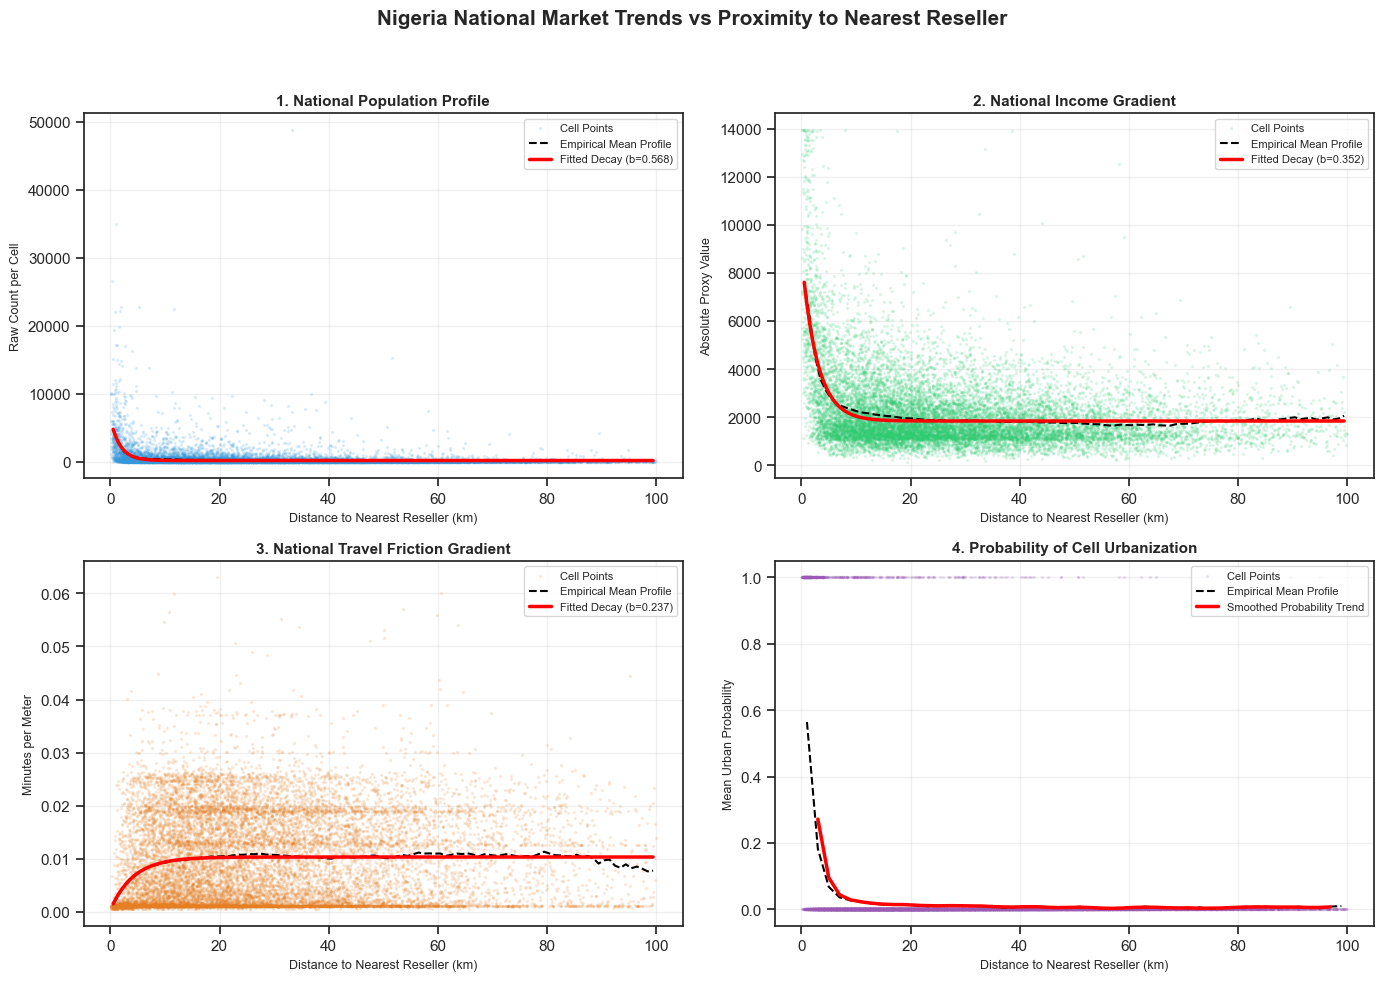

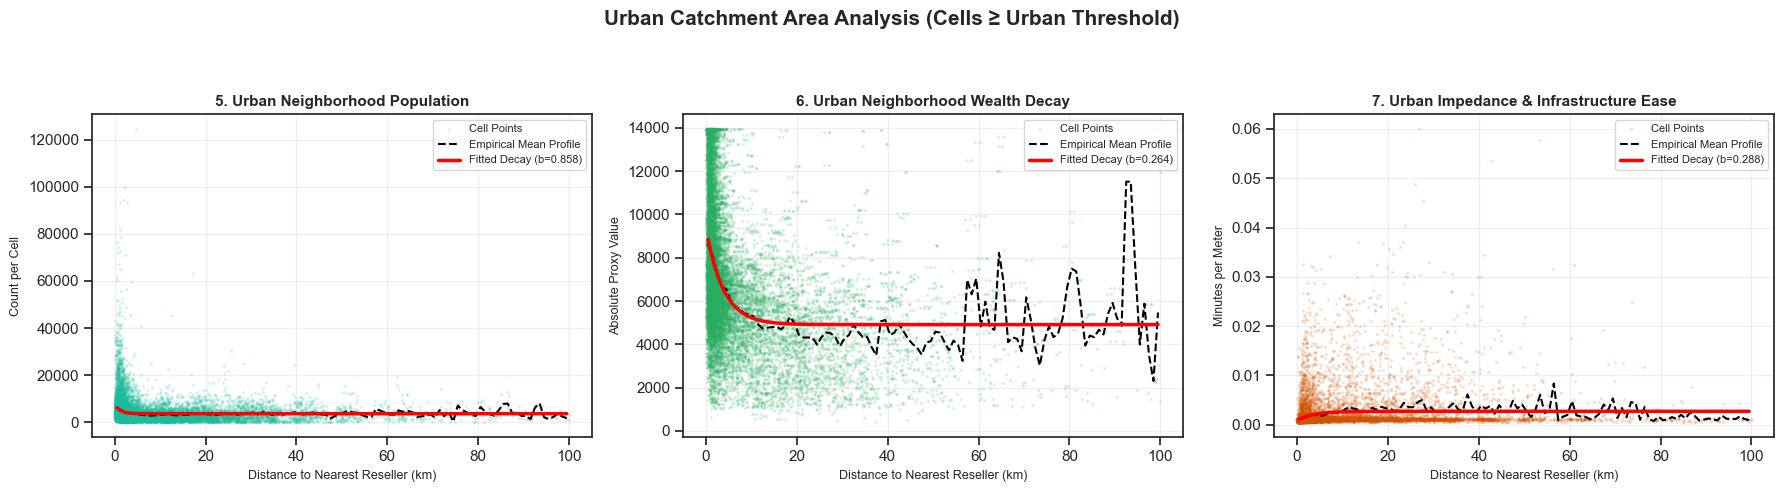

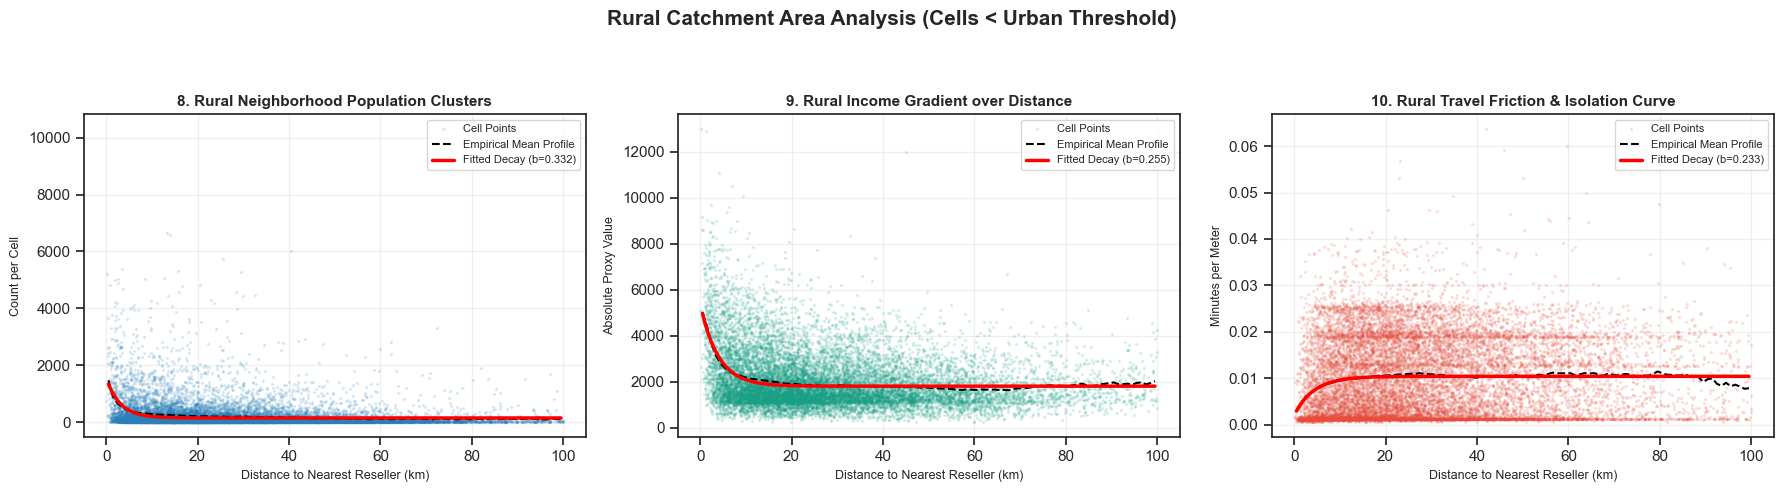

--- Distance-Decay Diagnostics Plots Built Successfully ---


In [2]:
# -----------------------------------------------------------------
# 8. DISTANCE-DECAY NEIGHBORHOOD PROFILE ANALYSIS
# -----------------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import curve_fit

print("\n--- Starting Distance-Decay Neighborhood Analysis ---")

# 8.1 Extract Coordinate Centers for Every Grid Cell
print("Extracting cell spatial coordinates...")
rows, cols = np.where(valid_cells)
# Convert grid array indices into projected coordinate centers (EPSG:3857 meters)
x_coords, y_coords = rasterio.transform.xy(ref_transform, rows, cols)
cell_coords = np.column_stack([x_coords, y_coords])

# 8.2 Build Spatial Index and Calculate Distances
print("Building KD-Tree for proximity extraction...")
resell_coords = np.array([(p.x, p.y) for p in resell.geometry])
resell_tree = cKDTree(resell_coords)

# Query tree for the distance from every grid cell to the nearest reseller
distances_m, _ = resell_tree.query(cell_coords)
distances_km = distances_m / 1000.0  # Convert meters to kilometers

# 8.3 Assemble Analytical DataFrame
df_trends = pd.DataFrame({
    'distance_km': distances_km,
    'population': pop_data[valid_cells],
    'income': income_data[valid_cells],
    'friction': friction_data[valid_cells],
    'is_urban': urban_mask[valid_cells].astype(int)
})

# Filter out extreme spatial outliers for clean visualization axes
MAX_DIST_PLOT_KM = 100.0
df_trends_filtered = df_trends[df_trends['distance_km'] <= MAX_DIST_PLOT_KM]

# Segment the continuous dataset into complete Urban and Rural subsets
df_urban = df_trends_filtered[df_trends_filtered['is_urban'] == 1]
df_rural = df_trends_filtered[df_trends_filtered['is_urban'] == 0]

print(f"Total cells processed within {MAX_DIST_PLOT_KM}km radius: {len(df_trends_filtered)}")
print(f" -> Urban Catchment Cells: {len(df_urban)}")
print(f" -> Rural Catchment Cells: {len(df_rural)}")

# 8.4 Mathematical Functions for Non-Linear Trend Analysis
def exp_decay_func(x, a, b, c):
    """Classic Negative Exponential Decay Function: y = a * exp(-b * x) + c"""
    return a * np.exp(-b * x) + c

def generate_trend_plot(ax, df_source, y_col, title, ylabel, color_theme, sample_size=15000, is_binary=False):
    """
    Generates a professional spatial trend graph blending an underlying mass of data points
    with a mathematically derived profile trend line.
    """
    # 1. Plot the representative underlying background mass of points
    sample_df = df_source.sample(n=min(sample_size, len(df_source)), random_state=42)
    ax.scatter(sample_df['distance_km'], sample_df[y_col], color=color_theme, alpha=0.12, s=2, label='Cell Points')
    
    # 2. Compute exact mean profiles using moving window distance bins over the ENTIRE dataset
    bin_width_km = 1.0 if not is_binary else 2.0
    df_source_binned = df_source.copy()
    df_source_binned['dist_bin'] = (df_source_binned['distance_km'] // bin_width_km) * bin_width_km + (bin_width_km / 2.0)
    
    profile_summary = df_source_binned.groupby('dist_bin')[y_col].mean().reset_index()
    x_profile = profile_summary['dist_bin'].values
    y_profile = profile_summary[y_col].values
    
    # Plot the empirical step-wise mean profile line
    ax.plot(x_profile, y_profile, color='black', linestyle='--', linewidth=1.5, label='Empirical Mean Profile')
    
    # 3. Fit a mathematical Negative Exponential Curve to check structural Distance-Decay
    if not is_binary and len(x_profile) > 3:
        try:
            # Provide stable starting coefficients [amplitude, decay rate, baseline offset]
            p0_initial = [y_profile.max() - y_profile.min(), 0.1, y_profile.min()]
            fitted_params, _ = curve_fit(exp_decay_func, x_profile, y_profile, p0=p0_initial, maxfev=5000)
            
            x_curve_smooth = np.linspace(x_profile.min(), x_profile.max(), 300)
            y_curve_fitted = exp_decay_func(x_curve_smooth, *fitted_params)
            
            ax.plot(x_curve_smooth, y_curve_fitted, color='red', linewidth=2.5, 
                    label=f'Fitted Decay (b={fitted_params[1]:.3f})')
        except RuntimeError:
            # Fallback smoothly to a smoothed rolling average if parameters fail to converge
            ax.plot(x_profile, pd.Series(y_profile).rolling(window=3, center=True).mean(), 
                    color='red', linewidth=2.5, label='Smoothed Rolling Trend')
    else:
        # For structural binary/probability variables, use a rolling average curve
        ax.plot(x_profile, pd.Series(y_profile).rolling(window=3, center=True).mean(), 
                color='red', linewidth=2.5, label='Smoothed Probability Trend')
        
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Distance to Nearest Reseller (km)', fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right', fontsize=8)

# -----------------------------------------------------------------
# 8.5 PLOT MASTER GENERATOR: THE 10 GEOGRAPHIC DASHBOARDS
# -----------------------------------------------------------------
sns.set_theme(style='ticks')

# --- PLOT SET 1: GLOBAL INFRASTRUCTURE TRENDS (Graphs 1 to 4) ---
fig1, axes1 = plt.subplots(2, 2, figsize=(14, 10))
fig1.suptitle('Nigeria National Market Trends vs Proximity to Nearest Reseller', fontsize=15, fontweight='bold')

generate_trend_plot(axes1[0,0], df_trends_filtered, 'population', '1. National Population Profile', 'Raw Count per Cell', '#3498db')
generate_trend_plot(axes1[0,1], df_trends_filtered, 'income', '2. National Income Gradient', 'Absolute Proxy Value', '#2ecc71')
generate_trend_plot(axes1[1,0], df_trends_filtered, 'friction', '3. National Travel Friction Gradient', 'Minutes per Meter', '#e67e22')
generate_trend_plot(axes1[1,1], df_trends_filtered, 'is_urban', '4. Probability of Cell Urbanization', 'Mean Urban Probability', '#9b59b6', is_binary=True)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# --- PLOT SET 2: STRATIFIED URBAN PROFILE (Graphs 5 to 7) ---
fig2, axes2 = plt.subplots(1, 3, figsize=(18, 5))
fig2.suptitle('Urban Catchment Area Analysis (Cells ≥ Urban Threshold)', fontsize=15, fontweight='bold')

generate_trend_plot(axes2[0], df_urban, 'population', '5. Urban Neighborhood Population', 'Count per Cell', '#1abc9c')
generate_trend_plot(axes2[1], df_urban, 'income', '6. Urban Neighborhood Wealth Decay', 'Absolute Proxy Value', '#27ae60')
generate_trend_plot(axes2[2], df_urban, 'friction', '7. Urban Impedance & Infrastructure Ease', 'Minutes per Meter', '#d35400')

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

# --- PLOT SET 3: STRATIFIED RURAL PROFILE (Graphs 8 to 10) ---
fig3, axes3 = plt.subplots(1, 3, figsize=(18, 5))
fig3.suptitle('Rural Catchment Area Analysis (Cells < Urban Threshold)', fontsize=15, fontweight='bold')

generate_trend_plot(axes3[0], df_rural, 'population', '8. Rural Neighborhood Population Clusters', 'Count per Cell', '#2980b9')
generate_trend_plot(axes3[1], df_rural, 'income', '9. Rural Income Gradient over Distance', 'Absolute Proxy Value', '#16a085')
generate_trend_plot(axes3[2], df_rural, 'friction', '10. Rural Travel Friction & Isolation Curve', 'Minutes per Meter', '#e74c3c')

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

print("--- Distance-Decay Diagnostics Plots Built Successfully ---")